In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data

In [ ]:
df = pd.read_csv('cleaned_data.csv')
df['genres'] = df['genres'].apply(lambda x: x.split(';') if pd.notnull(x) else [])
df.head()

,url,title,genres,description
0,https://www.filmweb.pl/film/Zielona+mila-1999-862,Zielona mila,[Dramat],Rok 1935. Paul Edgecombe (Tom Hanks) jest jedn...
1,https://www.filmweb.pl/film/Skazani+na+Shawsha...,Skazani na Shawshank,[Dramat],Film nakręcony na podstawie książki mistrza ho...
2,https://www.filmweb.pl/film/Forrest+Gump-1994-998,Forrest Gump,"[Dramat, Komedia]","""Forrest Gump"" to romantyczna historia, w któr..."
3,https://www.filmweb.pl/film/Leon+zawodowiec-19...,Leon zawodowiec,"[Dramat, Kryminał]",Leon (Jean Reno) jest płatnym zabójcą. W niczy...
4,https://www.filmweb.pl/film/Requiem+dla+snu-20...,Requiem dla snu,[Dramat],Wstrząsająca opowieść o czwórce bohaterów z Br...


## Genres

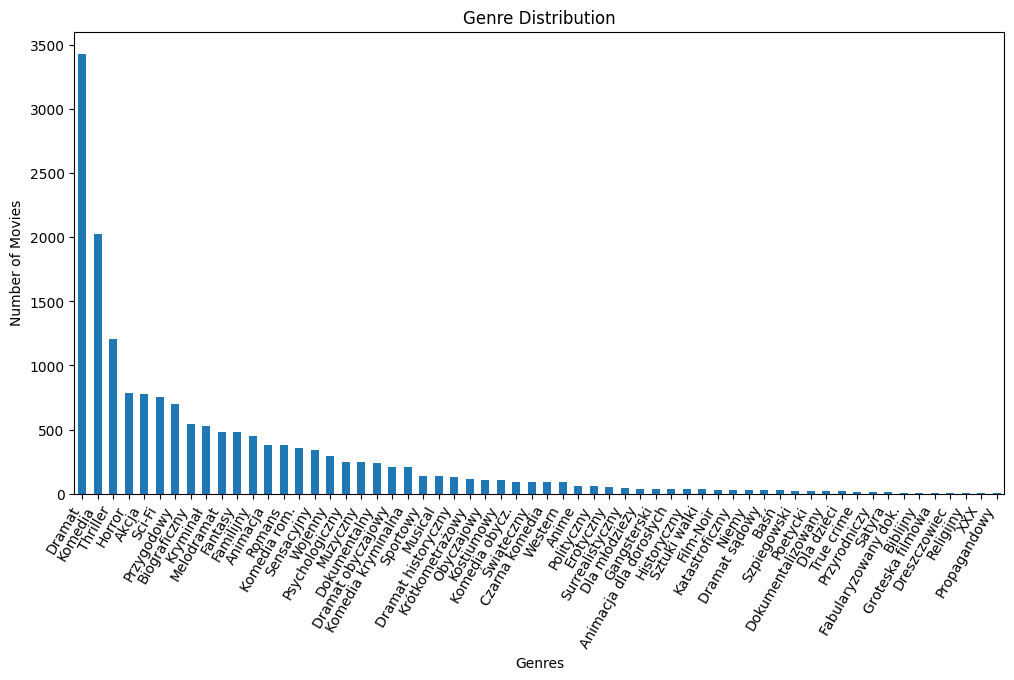

In [ ]:
genre_count = df['genres'].explode().value_counts()

genre_count.plot(kind='bar', title='Genre Distribution', ylabel='Number of Movies', xlabel='Genres', figsize=(12, 6))
plt.xticks(rotation=60, ha='right')
# plt.savefig('genre_distribution.png')
plt.show()

In [ ]:
print(genre_count)

genres
Dramat                    3432
Komedia                   2025
Thriller                  1205
Horror                     788
Akcja                      781
Sci-Fi                     757
Przygodowy                 699
Biograficzny               540
Kryminał                   529
Melodramat                 482
Fantasy                    480
Familijny                  446
Animacja                   382
Romans                     376
Komedia rom.               355
Sensacyjny                 341
Wojenny                    292
Psychologiczny             247
Muzyczny                   244
Dokumentalny               241
Dramat obyczajowy          210
Komedia kryminalna         207
Sportowy                   140
Musical                    138
Dramat historyczny         127
Krótkometrażowy            117
Obyczajowy                 109
Kostiumowy                 104
Komedia obycz.              94
Świąteczny                  94
Czarna komedia              91
Western                     87
A

In [ ]:
num_unique_genres = genre_count.shape[0]
print(f'Number of unique genres: {num_unique_genres}')

Number of unique genres: 60


In [ ]:
average_genres_per_movie = genre_count.sum() / df.shape[0]
print(f'Average number of genres per movie: {average_genres_per_movie:.2f}')

Average number of genres per movie: 1.77


In [ ]:
genres = df['genres'].explode().unique()
list(genres)

['Dramat',
 'Komedia',
 'Kryminał',
 'Sci-Fi',
 'Akcja',
 'Thriller',
 'Dramat historyczny',
 'Gangsterski',
 'Przygodowy',
 'Fantasy',
 'Familijny',
 'Dramat obyczajowy',
 'Biograficzny',
 'Kostiumowy',
 'Horror',
 'Melodramat',
 'Psychologiczny',
 'Dreszczowiec',
 'Animacja',
 'Polityczny',
 'Erotyczny',
 'Komedia kryminalna',
 'Sportowy',
 'Wojenny',
 'Czarna komedia',
 'Musical',
 'Romans',
 'Dokumentalny',
 'Sensacyjny',
 'Western',
 'Komedia obycz.',
 'Historyczny',
 'Komedia rom.',
 'Krótkometrażowy',
 'Groteska filmowa',
 'Satyra',
 'Szpiegowski',
 'Świąteczny',
 'Muzyczny',
 'Surrealistyczny',
 'Anime',
 'Obyczajowy',
 'Poetycki',
 'Dla dzieci',
 'Sztuki walki',
 'Dla młodzieży',
 'Biblijny',
 'Niemy',
 'Katastroficzny',
 'Dramat sądowy',
 'Animacja dla dorosłych',
 'Baśń',
 'Film-Noir',
 'Dokumentalizowany',
 'Religijny',
 'Fabularyzowany dok.',
 'XXX',
 'True crime',
 'Przyrodniczy',
 'Propagandowy']

## Descriptions

In [ ]:
df['description_word_count'] = df['description'].apply(lambda x: len(str(x).split()))
average_word_count = df['description_word_count'].mean()
print(f'Average word count in descriptions: {average_word_count:.2f}')
print(f'Maximum word count in descriptions: {df["description_word_count"].max()}')
print(f'Minimum word count in descriptions: {df["description_word_count"].min()}')

Average word count in descriptions: 81.74
Maximum word count in descriptions: 555
Minimum word count in descriptions: 14


# Model

In [ ]:
from tqdm import tqdm
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from src.herbert_classifier import HerBERTFrozenMultiLabelClassifier, HerBERTMultiLabelClassifier
from src.dataset import MoviesDataset


c:\Users\Katarzyna\movie-genre-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
device

('cuda',)

In [ ]:
def train_model(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    num_epochs: int,
    learning_rate: float = 1e-4,
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
    weights = None,
    threshold: float = 0.25
) -> tuple[torch.nn.Module, dict]:
    """
    Uniwersalna funkcja trenująca model.

    Args:
        model: Model PyTorch
        train_loader: DataLoader zbioru treningowego
        val_loader: DataLoader zbioru walidacyjnego
        num_epochs: Liczba epok
        learning_rate: Współczynnik uczenia
        device: Urządzenie ('cuda' lub 'cpu')
        weights: Wagi dla klas (opcjonalne). Może być pandas.Series, listą lub torch.Tensor.
        threshold: Próg klasyfikacji (domyślnie 0.5)
    """

    history = {
        "train_loss": [],
        "val_loss": [],
        "label_wise_accuracy": [],
        "sample_wise_accuracy": [],
        "f1_macro": [],
        "f1_micro": []
    }

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # Obsługa wag (weighted loss)
    if weights is not None:
        if not isinstance(weights, torch.Tensor):
            # Jeśli to pandas Series/DataFrame, weź .values, w przeciwnym razie użyj obiektu bezpośrednio
            vals = weights.values if hasattr(weights, 'values') else weights
            pos_weight = torch.tensor(vals, dtype=torch.float32).to(device)
        else:
            pos_weight = weights.to(device)

        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = torch.nn.BCEWithLogitsLoss()

    for epoch in range(num_epochs):
        # Training
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training'):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device).float()

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        all_labels = []
        all_preds = []
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Validation'):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device) # .float() ?

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(logits, labels) # .float() ?
                val_loss += loss.item()

                probabilities = torch.sigmoid(logits)
                predictions = (probabilities > threshold).int()

                all_labels.append(labels.cpu())
                all_preds.append(predictions.cpu())

        avg_val_loss = val_loss / len(val_loader)

        all_labels = torch.cat(all_labels)
        all_preds = torch.cat(all_preds)

        label_wise_accuracy = (all_labels == all_preds).float().mean().item() # label-wise accuracy
        sample_wise_accuracy = ((all_labels == all_preds).all(dim=1)).float().mean().item() # sample-wise accuracy
        f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0) # F1 score
        f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0) # Micro F1 score

        history["train_loss"].append(avg_loss)
        history["val_loss"].append(avg_val_loss)
        history["label_wise_accuracy"].append(label_wise_accuracy)
        history["sample_wise_accuracy"].append(sample_wise_accuracy)
        history["f1_macro"].append(f1_macro)
        history["f1_micro"].append(f1_micro)

        print(f'Epoch {epoch + 1}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
        print(f'Metrics: Label-wise Acc: {label_wise_accuracy:.4f}, Sample-wise Acc: {sample_wise_accuracy:.4f}, F1 Macro: {f1_macro:.4f}, F1 Micro: {f1_micro:.4f}')

    return model, history

In [ ]:
def build_label_mappings(df: pd.DataFrame) -> tuple[dict, dict]:
	all_genres = df['genres'].explode().unique()
	genre_to_idx = {genre: idx for idx, genre in enumerate(all_genres)}
	index_to_genre = {idx: genre for genre, idx in genre_to_idx.items()}
	return genre_to_idx, index_to_genre

def build_dataset(df: pd.DataFrame, genre_to_idx: dict, tokenizer_name: str="allegro/herbert-base-cased", max_length: int=512) -> MoviesDataset:
	num_labels = len(genre_to_idx)

	# Multi-hot encoding of genres
	def encode_genres(genres_list):
		vec = np.zeros(num_labels, dtype=int)
		for genre in genres_list:
			if genre in genre_to_idx:
				vec[genre_to_idx[genre]] = 1
		return vec
	labels = df['genres'].apply(encode_genres).tolist()

	# Tokenization
	tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
	encodings = tokenizer(
		df['description'].tolist(),
		padding=True,
		truncation=True,
		max_length=max_length
	)

	dataset = MoviesDataset(encodings, labels)

	return dataset

def create_data_loaders(
    df: pd.DataFrame,
    test_size: float = 0.2,
    random_state: int = 42,
    batch_size: int = 16
) -> tuple[DataLoader, DataLoader, dict, dict]:
	"""
	Create training and validation DataLoaders from the DataFrame.

	Args:
		df: DataFrame with 'description' and 'genres' columns
		test_size: Proportion of data to use for validation
		random_state: Random seed for reproducibility
		batch_size: Batch size for DataLoaders
	"""
	train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state)

	genre_to_idx, index_to_genre = build_label_mappings(df)

	train_dataset = build_dataset(train_df, genre_to_idx)
	val_dataset = build_dataset(val_df, genre_to_idx)

	train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
	val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

	return train_loader, val_loader, genre_to_idx, index_to_genre

In [ ]:
full_df = df.copy()

In [ ]:
import spacy
from spacy.lang.pl.stop_words import STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, f1_score

nlp = spacy.load("pl_core_news_sm")

In [ ]:

def preprocess_polish(text: str) -> str:
	"""
	Preprocess polish language with :
	1. Lowercasing
	2. Lemmatization
	3. Stop words removal
	4. Alphanumeric filtering
	"""

	doc = nlp(text.lower())

	tokens = [
		token.lemma_ for token in doc
		if token.is_alpha and token.lemma_ not in STOP_WORDS
	]
	return ' '.join(tokens)

In [ ]:
df['processed_description'] = df['description'].apply(preprocess_polish)

In [ ]:
df.to_csv('processed_data.csv', index=False)

# Data subsets

In [ ]:
def create_dataset_with_top_genres(df: pd.DataFrame, n: int, plot: bool = True) -> pd.DataFrame:
	"""
	Tworzy nowy DataFrame zawierający tylko n najpopularniejszych gatunków.
	"""
	genre_counts = df['genres'].explode().value_counts()
	top_genres = genre_counts.head(n).index.tolist()

	print(f"Wybrane {n} najpopularniejszych gatunków: {top_genres}")

	df_filtered = df.copy()
	df_filtered['genres'] = df_filtered['genres'].apply(lambda x: [g for g in x if g in top_genres])

	# Usunięcie filmów, które nie mają żadnego z wybranych gatunków
	df_filtered = df_filtered[df_filtered['genres'].map(len) > 0].reset_index(drop=True)

	print(f"Rozmiar oryginalnego zbioru: {len(df)}")
	print(f"Rozmiar przefiltrowanego zbioru: {len(df_filtered)}")

	if plot:
		genre_count_top = df_filtered['genres'].explode().value_counts()

		genre_count_top.plot(
			kind='bar',
			figsize=(12, 6),
			title='Genre Distribution (df_top_10)',
			ylabel='Number of Movies',
			xlabel='Genres'
		)
		plt.xticks(rotation=60, ha='right')
		plt.tight_layout()
		plt.show()

	return df_filtered

Wybrane 10 najpopularniejszych gatunków: ['Dramat', 'Komedia', 'Thriller', 'Horror', 'Akcja', 'Sci-Fi', 'Przygodowy', 'Biograficzny', 'Kryminał', 'Melodramat']
Rozmiar oryginalnego zbioru: 9519
Rozmiar przefiltrowanego zbioru: 7823


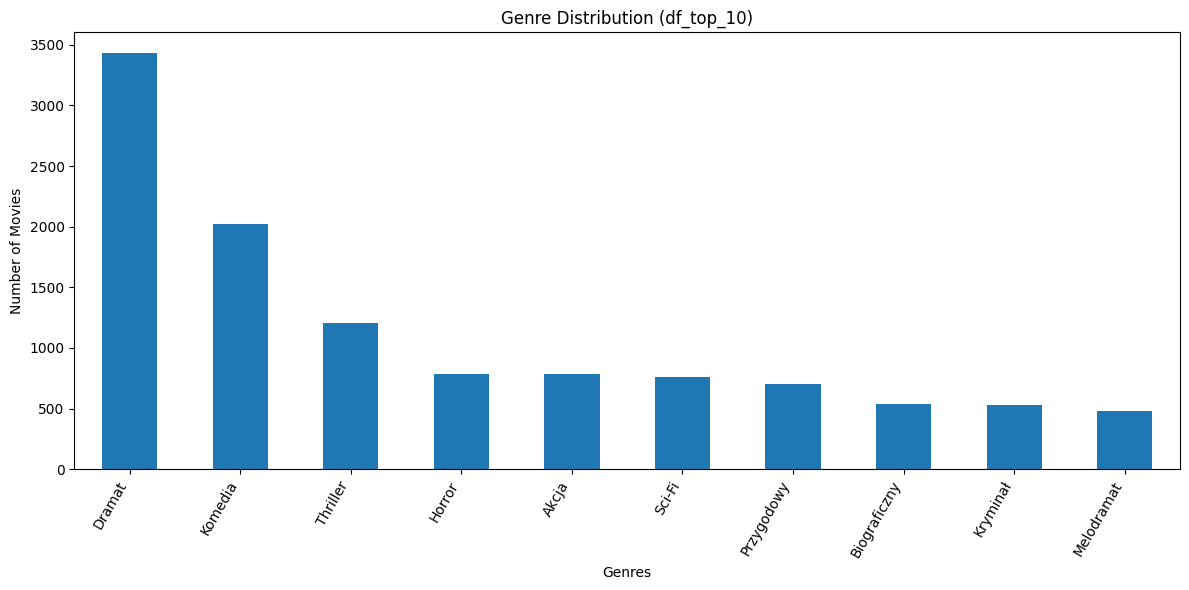

In [ ]:
df_top_10 = create_dataset_with_top_genres(df, n=10)

### Results for TF_IDF and BOW

In [ ]:
train_loader_10, validation_loader_10, genre_to_idx_10, idx_to_genre_10 = create_data_loaders(df_top_10, batch_size=16)

In [ ]:
def predict_genres(
    model: torch.nn.Module,
    tokenizer,
    texts: list[str] | str,
    idx_to_genre: dict,
    true_genres: list[list[str]] = None,
    threshold: float = 0.25,
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Predict genres for given text(s) using the trained model.

    Args:
        model: Trained PyTorch model
        tokenizer: Tokenizer used for the model
        texts: Single string or list of strings to predict
        idx_to_genre: Dictionary mapping indices to genre names
        true_genres: Optional list of true genres for comparison
        threshold: Probability threshold for classification
        device: Device to run prediction on
    """
    model.eval()
    model.to(device)

    if isinstance(texts, str):
        texts = [texts]

    # Tokenization
    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )

    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    with torch.no_grad():
        # Use model.predict with return_probs=True to get probabilities
        _, probabilities = model.predict(input_ids, attention_mask, threshold=threshold, return_probs=True)

    results = []
    for idx, probs in enumerate(probabilities):
        # Get indices where probability > threshold
        predicted_indices = (probs > threshold).nonzero().flatten().tolist()
        predicted_genres = [idx_to_genre[i] for i in predicted_indices]

        # Get probabilities for predicted genres
        genre_probs = {idx_to_genre[i]: probs[i].item() for i in range(len(probs))}

        # Sort all probabilities to show top ones
        sorted_probs = dict(sorted(genre_probs.items(), key=lambda item: item[1], reverse=True))

        results.append({
            'text': texts[idx],
            'predicted_genres': predicted_genres,
            'all_probabilities': sorted_probs
        })

        print(f"\n--- Text: {texts[idx][:100]}... ---")
        if true_genres is not None and idx < len(true_genres):
            print(f"True genres:      {true_genres[idx]}")
        print(f"Predicted genres: {predicted_genres}")
        print("Top 5 probabilities:")
        for genre, prob in list(sorted_probs.items())[:5]:
            print(f"  {genre}: {prob:.4f}")

    return results

## Balancing the subset

In [ ]:
import random
from collections import Counter

def balance_multilabel_dataset(df: pd.DataFrame, target_samples: int = None) -> pd.DataFrame:
    """
    Balansuje zbiór wieloetykietowy.

    Args:
        df: DataFrame z kolumną 'genres'
        target_samples: Docelowa liczba próbek dla każdej klasy.
                        Jeśli None, zostanie ustawiona na liczebność najrzadszej klasy w zbiorze.
    """
    # Kopia, żeby nie psuć oryginału
    df_balanced = df.copy()

    # 1. Mapa: gatunek -> lista indeksów wierszy, które go zawierają
    genre_to_indices = {}
    all_genres = df_balanced['genres'].explode().unique()

    # Upewniamy się, że pracujemy tylko na gatunkach obecnych w DataFrame
    # (Jeśli df to df_top_10, to all_genres będzie zawierać tylko te 10 gatunków)

    for genre in all_genres:
        # Znajdź indeksy wierszy zawierających dany gatunek
        indices = df_balanced[df_balanced['genres'].apply(lambda x: genre in x)].index.tolist()
        genre_to_indices[genre] = set(indices)

    # Jeśli target_samples nie jest podane, bierzemy minimum z liczebności klas
    if target_samples is None:
        counts = {g: len(indices) for g, indices in genre_to_indices.items()}
        min_genre = min(counts, key=counts.get)
        target_samples = counts[min_genre]
        print(f"Automatycznie ustawiono target_samples = {target_samples} (na podstawie najrzadszej klasy: '{min_genre}')")

    # 2. Sortujemy gatunki rosnąco po liczebności (najpierw rzadkie)
    sorted_genres = sorted(all_genres, key=lambda g: len(genre_to_indices[g]))

    selected_indices = set()
    current_counts = Counter()

    # 3. Główna pętla doboru
    for genre in sorted_genres:
        count_so_far = current_counts[genre]
        needed = target_samples - count_so_far

        if needed > 0:
            available = list(genre_to_indices[genre] - selected_indices)
            k = min(needed, len(available))
            picked_indices = random.sample(available, k)

            selected_indices.update(picked_indices)

            for idx in picked_indices:
                genres_in_movie = df_balanced.loc[idx, 'genres']
                for g in genres_in_movie:
                    current_counts[g] += 1

    return df_balanced.loc[list(selected_indices)].reset_index(drop=True)


Automatycznie ustawiono target_samples = 482 (na podstawie najrzadszej klasy: 'Melodramat')
Rozmiar przed balansowaniem: 7823
Rozmiar po balansowaniu: 3221


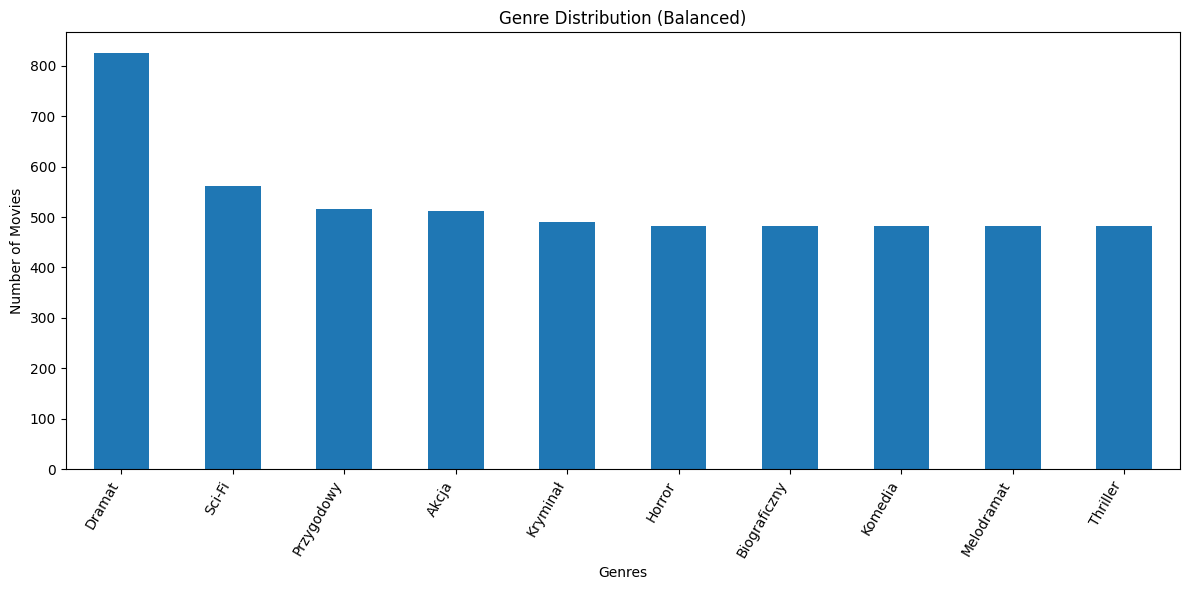

In [ ]:

# Użycie funkcji bez podawania target_samples (automatyczne wykrycie)
df_balanced = balance_multilabel_dataset(df_top_10, target_samples=None)

print(f"Rozmiar przed balansowaniem: {len(df_top_10)}")
print(f"Rozmiar po balansowaniu: {len(df_balanced)}")

# Wizualizacja
genre_count_balanced = df_balanced['genres'].explode().value_counts()
genre_count_balanced.plot(
    kind='bar',
    figsize=(12, 6),
    title='Genre Distribution (Balanced)',
    ylabel='Number of Movies',
    xlabel='Genres'
)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
genre_count_balanced = df_balanced['genres'].explode().value_counts()
genre_count_balanced

genres
Dramat          825
Sci-Fi          562
Przygodowy      515
Akcja           511
Kryminał        491
Horror          483
Biograficzny    482
Komedia         482
Melodramat      482
Thriller        482
Name: count, dtype: int64

In [ ]:
df_balanced.to_csv('balanced_data_2.csv', index=False)

In [ ]:
train_loader_balanced, validation_loader_balanced, genre_to_idx_balanced, idx_to_genre_balanced = create_data_loaders(df_balanced, batch_size=16)

In [ ]:
len(genre_to_idx_balanced)

10

In [ ]:
herbert_frozen = HerBERTFrozenMultiLabelClassifier(num_labels=len(genre_to_idx_balanced))

trained_model, _ = train_model(
    model=herbert_frozen,
    train_loader=train_loader_balanced,
	val_loader=validation_loader_balanced,
	num_epochs=50,
    threshold=0.3
)

Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.25it/s]


Epoch 1, Train Loss: 0.4860, Val Loss: 0.4370
Metrics: Label-wise Acc: 0.8384, Sample-wise Acc: 0.0000, F1 Macro: 0.0025, F1 Micro: 0.0038


Epoch 2/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.23it/s]


Epoch 2, Train Loss: 0.4470, Val Loss: 0.4338
Metrics: Label-wise Acc: 0.8372, Sample-wise Acc: 0.0000, F1 Macro: 0.0067, F1 Micro: 0.0113


Epoch 3/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.03it/s]


...

Epoch 48, Train Loss: 0.3643, Val Loss: 0.3789
Metrics: Label-wise Acc: 0.8245, Sample-wise Acc: 0.1271, F1 Macro: 0.3843, F1 Micro: 0.3998


Epoch 49/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.31it/s]


Epoch 49, Train Loss: 0.3623, Val Loss: 0.3780
Metrics: Label-wise Acc: 0.8273, Sample-wise Acc: 0.1302, F1 Macro: 0.3896, F1 Micro: 0.4043


Epoch 50/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.38it/s]

Epoch 50, Train Loss: 0.3597, Val Loss: 0.3783
Metrics: Label-wise Acc: 0.8260, Sample-wise Acc: 0.1287, F1 Macro: 0.3883, F1 Micro: 0.4032


In [ ]:
trained_model, _ = train_model(
    model=herbert_frozen,
    train_loader=train_loader_balanced,
	val_loader=validation_loader_balanced,
	num_epochs=50,
    threshold=0.3
)

Epoch 1/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.29it/s]


Epoch 1, Train Loss: 0.3600, Val Loss: 0.3781
Metrics: Label-wise Acc: 0.8257, Sample-wise Acc: 0.1318, F1 Macro: 0.3888, F1 Micro: 0.4059


Epoch 2/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.38it/s]


Epoch 2, Train Loss: 0.3607, Val Loss: 0.3775
Metrics: Label-wise Acc: 0.8257, Sample-wise Acc: 0.1380, F1 Macro: 0.3982, F1 Micro: 0.4134


Epoch 3/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.35it/s]


...

Epoch 48, Train Loss: 0.3355, Val Loss: 0.3721
Metrics: Label-wise Acc: 0.8209, Sample-wise Acc: 0.1411, F1 Macro: 0.4239, F1 Micro: 0.4330


Epoch 49/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.23it/s]


Epoch 49, Train Loss: 0.3336, Val Loss: 0.3719
Metrics: Label-wise Acc: 0.8155, Sample-wise Acc: 0.1411, F1 Macro: 0.4189, F1 Micro: 0.4295


Epoch 50/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.23it/s]

Epoch 50, Train Loss: 0.3358, Val Loss: 0.3727
Metrics: Label-wise Acc: 0.8163, Sample-wise Acc: 0.1302, F1 Macro: 0.4170, F1 Micro: 0.4256


In [ ]:
thresholds = [0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5]

In [ ]:
best_threshold_model_frozen, hist_of_best_model_frozen, best_threshold_frozen = None, None, None

for th in thresholds:
	model = HerBERTFrozenMultiLabelClassifier(num_labels=len(genre_to_idx_balanced))
	trained_model, history = train_model(
		model=model,
		train_loader=train_loader_balanced,
		val_loader=validation_loader_balanced,
		num_epochs=20,
		threshold=th
	)

	if best_threshold_model_frozen is None or history['f1_micro'][-1] > hist_of_best_model_frozen['f1_micro'][-1]:
		best_threshold_model_frozen = trained_model
		hist_of_best_model_frozen = history
		best_threshold_frozen = th

print(f"Best threshold: {best_threshold_frozen}")
print(f"Best model F1 Micro: {hist_of_best_model_frozen['f1_micro'][-1]:.4f}")
torch.save(best_threshold_model_frozen, "best_model_frozen.pth")


Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/20 Validation: 100%|██████████| 41/41 [00:05<00:00,  7.73it/s]


Epoch 1, Train Loss: 0.4829, Val Loss: 0.4402
Metrics: Label-wise Acc: 0.8367, Sample-wise Acc: 0.0000, F1 Macro: 0.0000, F1 Micro: 0.0000


Epoch 2/20 Validation: 100%|██████████| 41/41 [00:05<00:00,  7.71it/s]


Epoch 2, Train Loss: 0.4451, Val Loss: 0.4377
Metrics: Label-wise Acc: 0.8367, Sample-wise Acc: 0.0000, F1 Macro: 0.0000, F1 Micro: 0.0000


Epoch 3/20 Validation: 100%|██████████| 41/41 [00:05<00:00,  7.70it/s]


...

Epoch 18, Train Loss: 0.3873, Val Loss: 0.4039
Metrics: Label-wise Acc: 0.8410, Sample-wise Acc: 0.0124, F1 Macro: 0.0572, F1 Micro: 0.0604


Epoch 19/20 Validation: 100%|██████████| 41/41 [00:05<00:00,  7.73it/s]


Epoch 19, Train Loss: 0.3854, Val Loss: 0.4025
Metrics: Label-wise Acc: 0.8409, Sample-wise Acc: 0.0124, F1 Macro: 0.0605, F1 Micro: 0.0638


Epoch 20/20 Validation: 100%|██████████| 41/41 [00:05<00:00,  7.73it/s]


Epoch 20, Train Loss: 0.3843, Val Loss: 0.4019
Metrics: Label-wise Acc: 0.8409, Sample-wise Acc: 0.0124, F1 Macro: 0.0657, F1 Micro: 0.0688
Best threshold: 0.3
Best model F1 Micro: 0.2757


In [ ]:
best_threshold_model_frozen, hist_of_best_model_frozen, best_threshold_frozen = None, None, None

for th in (0.2, 0.4, 0.02):
	model = HerBERTFrozenMultiLabelClassifier(num_labels=len(genre_to_idx_balanced))
	trained_model, history = train_model(
		model=model,
		train_loader=train_loader_balanced,
		val_loader=validation_loader_balanced,
		num_epochs=20,
		threshold=th
	)

	if best_threshold_model_frozen is None or history['f1_micro'][-1] > hist_of_best_model_frozen['f1_micro'][-1]:
		best_threshold_model_frozen = trained_model
		hist_of_best_model_frozen = history
		best_threshold_frozen = th

print(f"Best threshold: {best_threshold_frozen}")
print(f"Best model F1 Micro: {hist_of_best_model_frozen['f1_micro'][-1]:.4f}")
torch.save(best_threshold_model_frozen, "best_model_frozen.pth")

Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/20 Validation: 100%|██████████| 41/41 [00:07<00:00,  5.66it/s]


Epoch 1, Train Loss: 0.4814, Val Loss: 0.4428
Metrics: Label-wise Acc: 0.7853, Sample-wise Acc: 0.0000, F1 Macro: 0.0470, F1 Micro: 0.2001


Epoch 2/20 Validation: 100%|██████████| 41/41 [00:07<00:00,  5.71it/s]


Epoch 2, Train Loss: 0.4449, Val Loss: 0.4398
Metrics: Label-wise Acc: 0.7847, Sample-wise Acc: 0.0031, F1 Macro: 0.0642, F1 Micro: 0.2078


Epoch 3/20 Validation: 100%|██████████| 41/41 [00:07<00:00,  5.60it/s]


...

Epoch 18, Train Loss: 0.3887, Val Loss: 0.4000
Metrics: Label-wise Acc: 0.1724, Sample-wise Acc: 0.0000, F1 Macro: 0.2830, F1 Micro: 0.2848


Epoch 19/20 Validation: 100%|██████████| 41/41 [00:07<00:00,  5.58it/s]


Epoch 19, Train Loss: 0.3866, Val Loss: 0.3987
Metrics: Label-wise Acc: 0.1735, Sample-wise Acc: 0.0000, F1 Macro: 0.2831, F1 Micro: 0.2849


Epoch 20/20 Validation: 100%|██████████| 41/41 [00:07<00:00,  5.55it/s]


Epoch 20, Train Loss: 0.3853, Val Loss: 0.3979
Metrics: Label-wise Acc: 0.1744, Sample-wise Acc: 0.0000, F1 Macro: 0.2833, F1 Micro: 0.2851
Best threshold: 0.2
Best model F1 Micro: 0.4187


In [ ]:
best_threshold_model, hist_of_best_model, best_threshold = None, None, None

for th in thresholds:
	model = HerBERTMultiLabelClassifier(num_labels=len(genre_to_idx_balanced))
	trained_model, history = train_model(
		model=model,
		train_loader=train_loader_balanced,
		val_loader=validation_loader_balanced,
		num_epochs=20,
		threshold=th
	)

	if best_threshold_model is None or history['f1_micro'][-1] > hist_of_best_model['f1_micro'][-1]:
		best_threshold_model = trained_model
		hist_of_best_model = history
		best_threshold = th

print(f"Best threshold: {best_threshold}")
print(f"Best model F1 Micro: {hist_of_best_model['f1_micro'][-1]:.4f}")

Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/20 Training:   2%|▏         | 3/162 [00:11<10:28,  3.95s/it]


KeyboardInterrupt: 

In [ ]:
model = HerBERTFrozenMultiLabelClassifier(num_labels=len(genre_to_idx_balanced))
trained_model, history = train_model(
  model=model,
  train_loader=train_loader_balanced,
  val_loader=validation_loader_balanced,
  num_epochs=50,
  threshold=0.2
)

Some weights of the model checkpoint at allegro/herbert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.04it/s]


Epoch 1, Train Loss: 0.4884, Val Loss: 0.4366
Metrics: Label-wise Acc: 0.7822, Sample-wise Acc: 0.0000, F1 Macro: 0.0540, F1 Micro: 0.1883


Epoch 2/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.59it/s]


Epoch 2, Train Loss: 0.4466, Val Loss: 0.4341
Metrics: Label-wise Acc: 0.7789, Sample-wise Acc: 0.0093, F1 Macro: 0.0902, F1 Micro: 0.2051


Epoch 3/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.09it/s]


...

Epoch 48, Train Loss: 0.3605, Val Loss: 0.3774
Metrics: Label-wise Acc: 0.7357, Sample-wise Acc: 0.0574, F1 Macro: 0.4254, F1 Micro: 0.4277


Epoch 49/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.31it/s]


Epoch 49, Train Loss: 0.3582, Val Loss: 0.3776
Metrics: Label-wise Acc: 0.7468, Sample-wise Acc: 0.0620, F1 Macro: 0.4210, F1 Micro: 0.4256


Epoch 50/50 Validation: 100%|██████████| 41/41 [00:06<00:00,  6.50it/s]

Epoch 50, Train Loss: 0.3597, Val Loss: 0.3769
Metrics: Label-wise Acc: 0.7405, Sample-wise Acc: 0.0620, F1 Macro: 0.4236, F1 Micro: 0.4259


In [ ]:
torch.save(best_threshold_model, "best_model.pth")